# Objective 4 — Reviewer Behavior Analysis

In this section, we analyze reviewer behavior in the beer review dataset. 
The goal is to understand whether certain reviewers show rating biases and whether experienced reviewers rate beers differently.

Key questions explored:
- Who are the most active reviewers?
- Do some reviewers consistently rate beers higher or lower than others?
- Does reviewer experience affect rating behavior?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Loding the cleaned dataset

In [10]:
df=pd.read_csv("Datasets/beer.csv")
df.head()

,review_id,beer_name,reviewer_username,overall_score,brewery_name,beer_style,beer_abv,aroma_score,appearance_score,taste_score,palate_score
0,1,Sausa Weizen,stcules,1.5,Unknown,AMERICAN IPA,<bound method Series.median of 0 NaN...,2.0,2.5,1.5,1.5
1,2,Red Moon,stcules,3.0,VECCHIO BIRRAIO,English Strong Ale,6.2,2.5,3.0,3.0,3.0
2,3,BLACK HORSE BLACK BEER,stcules,3.0,Unknown,AMERICAN IPA,<bound method Series.median of 0 NaN...,2.5,3.0,3.0,3.0
3,4,sausa pils,stcules,3.0,VECCHIO BIRRAIO,german pilsener,5.0,3.0,3.5,3.0,2.5
4,5,Cauldron Dipa,johnmichaelsen,4.0,Unknown,AMERICAN IPA,<bound method Series.median of 0 NaN...,4.5,4.0,4.5,4.0


In [11]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251441 entries, 0 to 251440
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   review_id          251441 non-null  int64  
 1   beer_name          251441 non-null  object 
 2   reviewer_username  251441 non-null  object 
 3   overall_score      251441 non-null  float64
 4   brewery_name       251441 non-null  object 
 5   beer_style         251441 non-null  object 
 6   beer_abv           251441 non-null  object 
 7   aroma_score        251441 non-null  float64
 8   appearance_score   251441 non-null  float64
 9   taste_score        251441 non-null  float64
 10  palate_score       251441 non-null  float64
dtypes: float64(5), int64(1), object(5)
memory usage: 21.1+ MB


In [12]:
df.columns

Index(['review_id', 'beer_name', 'reviewer_username', 'overall_score',
       'brewery_name', 'beer_style', 'beer_abv', 'aroma_score',
       'appearance_score', 'taste_score', 'palate_score'],
      dtype='object')

Reviewer activity analysis
-Analyzing how many reviews each reviewer has left to idenfity most active reviewers

In [14]:
review_counts=df.groupby("reviewer_username").size()
review_counts=review_counts.sort_values(ascending=False)
review_counts.head(10)

reviewer_username
northyorksammy     927
womencantsail      707
mikesgroove        704
BuckeyeNation      611
Thorpe429          586
Halcyondays        526
ChainGangGuy       520
brentk56           512
barleywinefiend    507
oberon             499
dtype: int64

## Most Active Reviewers

The following chart shows the reviewers who have contributed the highest number of reviews.

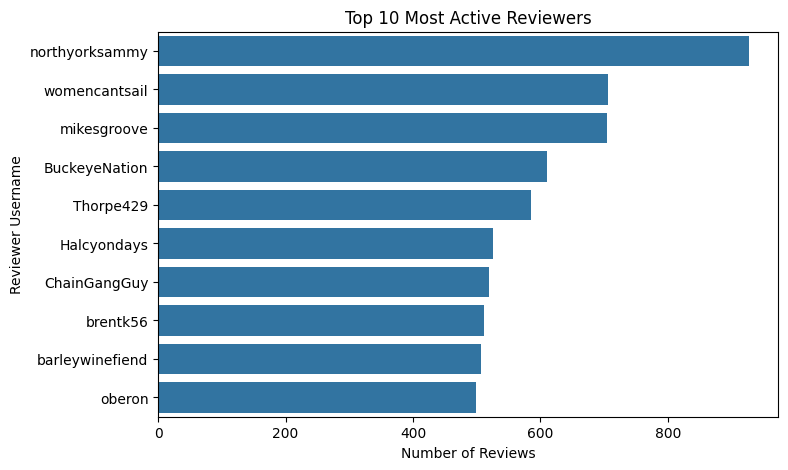

In [15]:
top_reviewers = review_counts.head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    x=top_reviewers.values,
    y=top_reviewers.index
)

plt.title("Top 10 Most Active Reviewers")
plt.xlabel("Number of Reviews")
plt.ylabel("Reviewer Username")

plt.show()

## Reviewer Rating Bias

Next, we analyze whether some reviewers consistently give higher or lower ratings compared to others.

We calculate the average rating given by each reviewer and also count how many reviews they have written.

In [ ]:
reviewer_stats = df.groupby("reviewer_username")["overall_score"].agg(["mean", "count"])

reviewer_stats = reviewer_stats[reviewer_stats["count"] >= 20]
reviewer_stats.head()

,mean,count
reviewer_username,,
0110x011,4.121622,37
100floods,4.070597,32
1759Girl,3.853657,34
1Adam12,3.766001,27
1fastz28,3.758964,55
